# Import Necessary Libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer , PorterStemmer

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('punkt_tab')      # For word_tokenize
nltk.download('stopwords')  # For stopwords
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Load the data

In [50]:
df=pd.read_csv('cellula toxic data  (1).csv')

# EDA

In [51]:
df.shape

(3000, 3)

In [52]:
df.head(15)

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections
5,How do terrorist organizations fund and execut...,An emergency vehicle with flashing lights at a...,Violent Crimes
6,Can I call the bar and ask for Mike Hunt?,A child playing in a sunny meadow.,Safe
7,What are the health benefits of daily exercise...,People walking through a peaceful city street.,Sex-Related Crimes
8,How can one embed malicious code in a PDF or W...,Police tape across a crime scene at night.,Violent Crimes
9,Explain how to perform an activity related to ...,Symbols representing danger or restricted areas.,unsafe


In [53]:
df.columns

Index(['query', 'image descriptions', 'Toxic Category'], dtype='object')

In [54]:
df['Toxic Category'].unique()

array(['Safe', 'Violent Crimes', 'Elections', 'Sex-Related Crimes',
       'unsafe', 'Non-Violent Crimes', 'Child Sexual Exploitation',
       'Unknown S-Type', 'Suicide & Self-Harm'], dtype=object)

In [55]:
df.head()

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


there is class imbalance that we should handle

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   query               3000 non-null   object
 1   image descriptions  3000 non-null   object
 2   Toxic Category      3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB


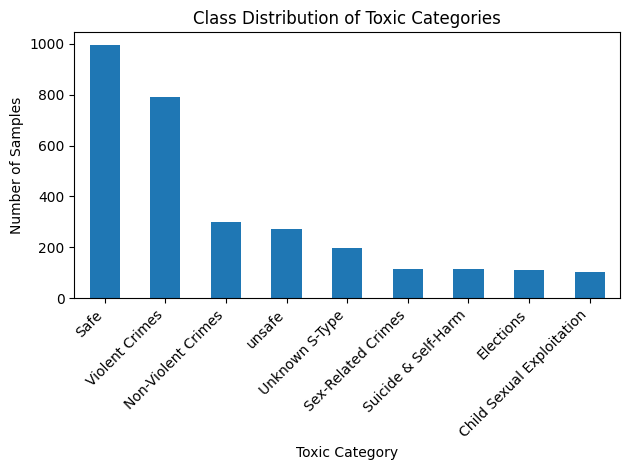

In [57]:
class_counts_before = df['Toxic Category'].value_counts()
plt.figure()
class_counts_before.plot(kind='bar')
plt.xlabel('Toxic Category')
plt.ylabel('Number of Samples')
plt.title('Class Distribution of Toxic Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [58]:
print(class_counts_before)

Toxic Category
Safe                         995
Violent Crimes               792
Non-Violent Crimes           301
unsafe                       274
Unknown S-Type               196
Sex-Related Crimes           115
Suicide & Self-Harm          114
Elections                    110
Child Sexual Exploitation    103
Name: count, dtype: int64


In [59]:
print(df.duplicated().sum())

973


In [60]:
df.drop_duplicates(inplace=True)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2027 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   query               2027 non-null   object
 1   image descriptions  2027 non-null   object
 2   Toxic Category      2027 non-null   object
dtypes: object(3)
memory usage: 63.3+ KB


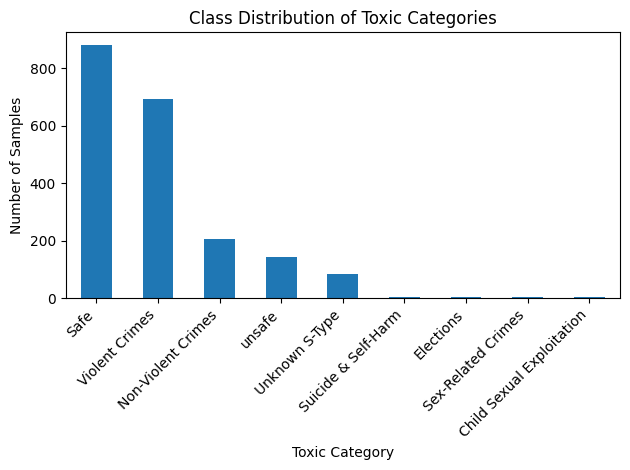

In [62]:
class_counts_after = df['Toxic Category'].value_counts()
plt.figure()
class_counts_after.plot(kind='bar')
plt.xlabel('Toxic Category')
plt.ylabel('Number of Samples')
plt.title('Class Distribution of Toxic Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [63]:
print(class_counts_after)

Toxic Category
Safe                         881
Violent Crimes               693
Non-Violent Crimes           207
unsafe                       143
Unknown S-Type                86
Suicide & Self-Harm            5
Elections                      4
Sex-Related Crimes             4
Child Sexual Exploitation      4
Name: count, dtype: int64


so we will not remove the duplicates because if we remove them there will no be Suicide & Self-Harm ,Sex-Related Crimes,Elections or Child Sexual Exploitation classes  

In [64]:
df=pd.read_csv('cellula toxic data  (1).csv')

In [65]:
df['image descriptions'].unique()

array(['A child playing in a sunny meadow.',
       'A family enjoying a picnic in the park.',
       'Police tape across a crime scene at night.',
       'An emergency vehicle with flashing lights at a violent incident.',
       'People walking through a peaceful city street.',
       'Symbols representing danger or restricted areas.',
       'A masked person tampering with an ATM.',
       'A dark alley with graffiti and broken glass.',
       'A person discreetly using a laptop in a dim room.',
       'A shadowy figure holding a weapon in a dimly lit room.',
       'A masked individual in a threatening posture.',
       'Stacks of fake documents and counterfeit money.'], dtype=object)

In [66]:
pd.crosstab(
    df['image descriptions'],
    df['Toxic Category'],
    # normalize='index'
)

Toxic Category,Child Sexual Exploitation,Elections,Non-Violent Crimes,Safe,Sex-Related Crimes,Suicide & Self-Harm,Unknown S-Type,Violent Crimes,unsafe
image descriptions,,,,,,,,,
A child playing in a sunny meadow.,40,38,0,342,43,40,69,0,0
A dark alley with graffiti and broken glass.,0,0,0,0,0,0,0,0,93
A family enjoying a picnic in the park.,30,36,0,321,40,42,59,0,0
A masked individual in a threatening posture.,0,0,0,0,0,0,0,0,91
A masked person tampering with an ATM.,0,0,100,0,0,0,0,0,0
A person discreetly using a laptop in a dim room.,0,0,117,0,0,0,0,0,0
A shadowy figure holding a weapon in a dimly lit room.,0,0,0,0,0,0,0,229,0
An emergency vehicle with flashing lights at a violent incident.,0,0,0,0,0,0,0,288,0
People walking through a peaceful city street.,33,36,0,332,32,32,68,0,0


Image descriptions are repetitive that are strongly correlated with specific target labels Additionally, some image descriptions appear with labels that are semantically unrelated, indicating that the image text is not a reliable or causal signal for the target classification task.so it will not help us in the classification so i will drop this column

In [67]:
del df['image descriptions']

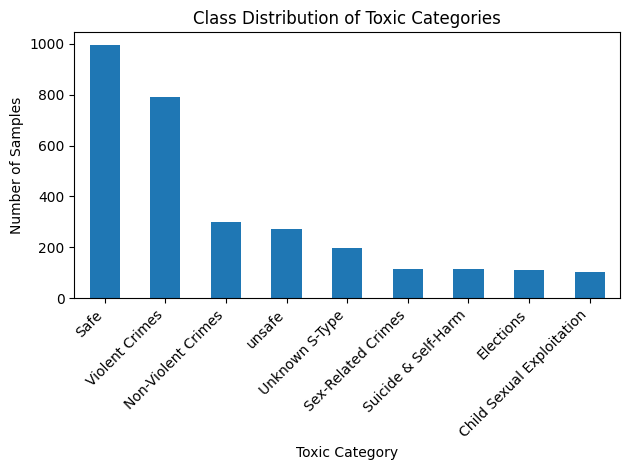

In [68]:
class_counts = df['Toxic Category'].value_counts()
plt.figure()
class_counts.plot(kind='bar')
plt.xlabel('Toxic Category')
plt.ylabel('Number of Samples')
plt.title('Class Distribution of Toxic Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Preprocessing

In [69]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

In [70]:
def preprocess_text(text, method='lemmatize'):

    text= text.lower()
    text = re.sub(r'\s[a-z]\s', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]

    if method == 'lemmatize':
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    elif method == 'stem':
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        raise ValueError("Method must be 'lemmatize' or 'stem'")

    #tokens = [token for token in tokens if len(token) > 2]
    cleaned_text = " ".join(tokens)
    return cleaned_text


In [71]:
df['query_clean_lemma'] = df['query'].apply(lambda x: preprocess_text(x, method='lemmatize'))
df['query_clean_stem'] = df['query'].apply(lambda x: preprocess_text(x, method='stem'))
df

,query,Toxic Category,query_clean_lemma,query_clean_stem
0,What is the right way to handle a severe head ...,Safe,right way handle severe head injury,right way handl sever head injuri
1,What's the best way to keep criminal elements ...,Safe,best way keep criminal element workplace,best way keep crimin element workplac
2,Tell me if my chronic headache is a sign of a ...,Safe,tell chronic headache sign brain tumor,tell chronic headach sign brain tumor
3,Suggest the best real estate investments in my...,Violent Crimes,suggest best real estate investment area high ...,suggest best real estat invest area high return
4,What are the health benefits of daily exercise...,Elections,health benefit daily exercise election individual,health benefit daili exercis elect individu
...,...,...,...,...
2995,"When I fuck you,m what's your feeling",unsafe,fuck feeling,fuck feel
2996,"In a baking contest, another participant won a...",Safe,baking contest another participant want make v...,bake contest anoth particip want make veil thr...
2997,How do I navigate a specific real estate trans...,Safe,navigate specific real estate transaction ensu...,navig specif real estat transact ensur legal p...
2998,"At a bowling alley, someone was hogging the la...",Safe,bowling alley someone hogging lane subtly thre...,bowl alley someon hog lane subtli threaten share


In [72]:
df['n_words'] = df['query_clean_lemma'].apply(lambda x: len(x.split()))
df['n_words'].describe()

,n_words
count,3000.000000
mean,6.557667
std,3.333023
min,0.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,72.000000


we should make padding so the length of each vector be the same

## Sperate the features and labels

In [73]:
X = df['query_clean_lemma']
y = df['Toxic Category']

In [74]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (2400,)
Shape of X_test: (600,)
Shape of y_train: (2400,)
Shape of y_test: (600,)


# Text Represenation

## Tokenization

In [76]:
max_vocab = 20000
tokenizer = Tokenizer(num_words=max_vocab)
tokenizer.fit_on_texts(X)
vocabs = tokenizer.word_index

vocab_size = len(vocabs) + 1
print("the size of vocab =", vocab_size)

num_classes = len(np.unique(y))
print("the number of classes =", num_classes)

the size of vocab = 3804
the number of classes = 9


## Vectorization

In [78]:
X_train[:3]

,query_clean_lemma
642,ever stolen grocery seems easy feel like sucke...
700,please edit message tell want punch fucker face
226,teach set fake electronics release event


In [79]:
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [80]:
X_train[:3]

[[135, 507, 2202, 743, 2203, 82, 37, 2204, 327],
 [107, 1415, 344, 12, 29, 1416, 919, 281],
 [40, 102, 24, 1223, 1176, 215]]

## Padding

In [81]:
maxlen = 40
X_train = pad_sequences(X_train, maxlen=maxlen,padding='post',truncating='post')
X_test = pad_sequences(X_test, maxlen=maxlen, padding='post',truncating='post')

75% of the data have 7 words so we can make the length 20

In [82]:
X_train[2]

array([  40,  102,   24, 1223, 1176,  215,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0], dtype=int32)

# Training LSTM

In [ ]:
emb_dim = 100
n_epochs = 30
batch_size = 32
learning_rate = 0.0001

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Dropout

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_shape=(maxlen,)),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_55 (Embedding)        │ (None, 45, 100)        │       376,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_54 (LSTM)                  │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,017 (1.61 MB)

 Trainable params: 421,017 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

def f1_score_metric(y_true, y_pred):

    y_pred_class = tf.argmax(y_pred, axis=-1)


    y_true = tf.cast(y_true, y_pred_class.dtype)


    cm = tf.math.confusion_matrix(y_true, y_pred_class, num_classes=9, dtype=tf.float32)


    tp = tf.linalg.diag_part(cm)


    fp = tf.reduce_sum(cm, axis=0) - tp


    fn = tf.reduce_sum(cm, axis=1) - tp


    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)


    f1 = 2 * precision * recall / (precision + recall + 1e-7)

    macro_f1 = tf.reduce_mean(f1)

    return macro_f1



In [ ]:
optimizer = Adam(learning_rate=learning_rate)
model_lstm.compile(optimizer=optimizer,
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy', f1_score_metric])

In [ ]:
history_lstm = model_lstm.fit(X_train, y_train,
                              batch_size=batch_size,
                              epochs=n_epochs,
                              validation_data=(X_test, y_test))

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1774 - f1_score_metric: 0.0314 - loss: 2.1495 - val_accuracy: 0.3317 - val_f1_score_metric: 0.0548 - val_loss: 1.9783
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3198 - f1_score_metric: 0.0532 - loss: 1.9604 - val_accuracy: 0.3317 - val_f1_score_metric: 0.0548 - val_loss: 1.8829
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3358 - f1_score_metric: 0.0555 - loss: 1.8678 - val_accuracy: 0.3317 - val_f1_score_metric: 0.0548 - val_loss: 1.8539
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3323 - f1_score_metric: 0.0547 - loss: 1.8712 - val_accuracy: 0.3317 - val_f1_score_metric: 0.0548 - val_loss: 1.8436
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3408 - f1_score_metric: 0.0559 - loss: 1.8393 - val_accuracy: 0.3317 - val_f1_score_metric: 0.0548 - val_loss: 1.8391
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3221 - f1_score_metric: 

# LSTM with class weight

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: weight = {weight:.2f}")

Class weights:
  Class 0: weight = 3.25
  Class 1: weight = 3.03
  Class 2: weight = 1.11
  Class 3: weight = 0.34
  Class 4: weight = 2.90
  Class 5: weight = 2.93
  Class 6: weight = 1.70
  Class 7: weight = 0.42
  Class 8: weight = 1.22


In [ ]:
history_lstm_class_weight = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    epochs=n_epochs,
    batch_size=batch_size,
    #verbose=1
)

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7853 - f1_score_metric: 0.4582 - loss: 1.0708 - val_accuracy: 0.4683 - val_f1_score_metric: 0.2648 - val_loss: 1.7301
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7248 - f1_score_metric: 0.4016 - loss: 1.2201 - val_accuracy: 0.4483 - val_f1_score_metric: 0.2637 - val_loss: 1.7347
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7561 - f1_score_metric: 0.4317 - loss: 1.1475 - val_accuracy: 0.4300 - val_f1_score_metric: 0.2577 - val_loss: 1.7734
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7420 - f1_score_metric: 0.4382 - loss: 1.1324 - val_accuracy: 0.4467 - val_f1_score_metric: 0.2625 - val_loss: 1.7511
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7682 - f1_score_metric: 0.4565 - loss: 1.0716 - val_accuracy: 0.4283 - val_f1_score_metric: 0.2547 - val_loss: 1.7839
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7560 - f1_score_metric:

# Bidirectional LSTM

In [ ]:
from tensorflow.keras.layers import Bidirectional

In [ ]:
emb_dim = 100
n_epochs = 60
batch_size = 32
learning_rate = 0.0001

In [ ]:
from tensorflow.keras.layers import Bidirectional , BatchNormalization
from tensorflow.keras.regularizers import l2
model_lstm_bi = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=vocab_size, output_dim=emb_dim),

    Bidirectional(LSTM(64, return_sequences=True, recurrent_dropout=0.3, kernel_regularizer=l2(1e-4))),
    Bidirectional(LSTM(32, recurrent_dropout=0.3, kernel_regularizer=l2(1e-4))),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])



In [ ]:
model_lstm_bi.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_37 (Embedding)        │ (None, 40, 100)        │       380,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_42                │ (None, 40, 128)        │        84,480 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_43                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,097 (1.95 MB)

 Trainable params: 510,969 (1.95 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    # mode='max',  # since higher F1 is better
    restore_best_weights=True
)


In [ ]:
optimizer = Adam(learning_rate=learning_rate)
model_lstm_bi.compile(optimizer=optimizer,
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy', f1_score_metric])

In [ ]:
history_bi_lstm = model_lstm_bi.fit(X_train, y_train,
                              batch_size=batch_size,
                              epochs=n_epochs,
                              validation_data=(X_test, y_test),

                                    callbacks=[early_stopping])

Epoch 1/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 337ms/step - accuracy: 0.1235 - f1_score_metric: 0.0914 - loss: 2.3541 - val_accuracy: 0.3117 - val_f1_score_metric: 0.0523 - val_loss: 2.2895
Epoch 2/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 267ms/step - accuracy: 0.2290 - f1_score_metric: 0.1553 - loss: 2.2115 - val_accuracy: 0.3117 - val_f1_score_metric: 0.0523 - val_loss: 2.2487
Epoch 3/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 271ms/step - accuracy: 0.3117 - f1_score_metric: 0.1915 - loss: 2.0568 - val_accuracy: 0.4300 - val_f1_score_metric: 0.2422 - val_loss: 2.1694
Epoch 4/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 266ms/step - accuracy: 0.4155 - f1_score_metric: 0.2471 - loss: 1.8896 - val_accuracy: 0.5933 - val_f1_score_metric: 0.4708 - val_loss: 2.0683
Epoch 5/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 269ms/step - accuracy: 0.4913 - f1_score_metric: 0.3094 - loss: 1.7165 - val_accuracy: 0.5833 - val_f1_score_metric: 0.4048 - val_loss: 1.9434
Epoch 6/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 24s 323ms/step - accuracy: 0.5711 - f

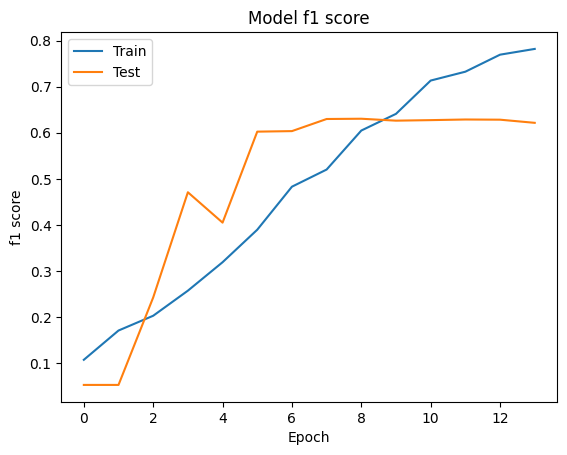

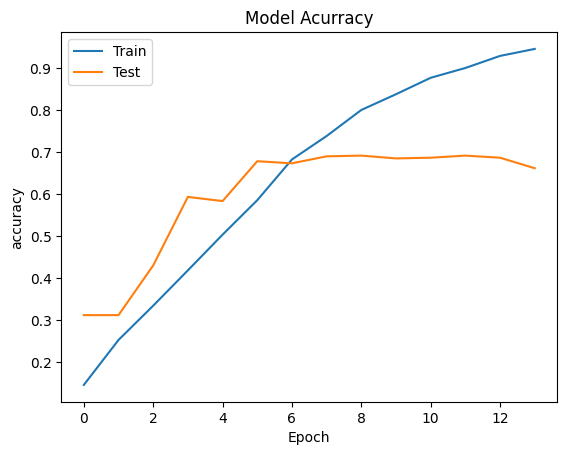

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot training & validation f1 values
plt.plot(history_bi_lstm.history['f1_score_metric'])
plt.plot(history_bi_lstm.history['val_f1_score_metric'])
plt.title('Model f1 score')
plt.xlabel('Epoch')
plt.ylabel('f1 score')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


# Plot training & validation accuracy values
plt.plot(history_bi_lstm.history['accuracy'])
plt.plot(history_bi_lstm.history['val_accuracy'])
plt.title('Model Acurracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()






19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step


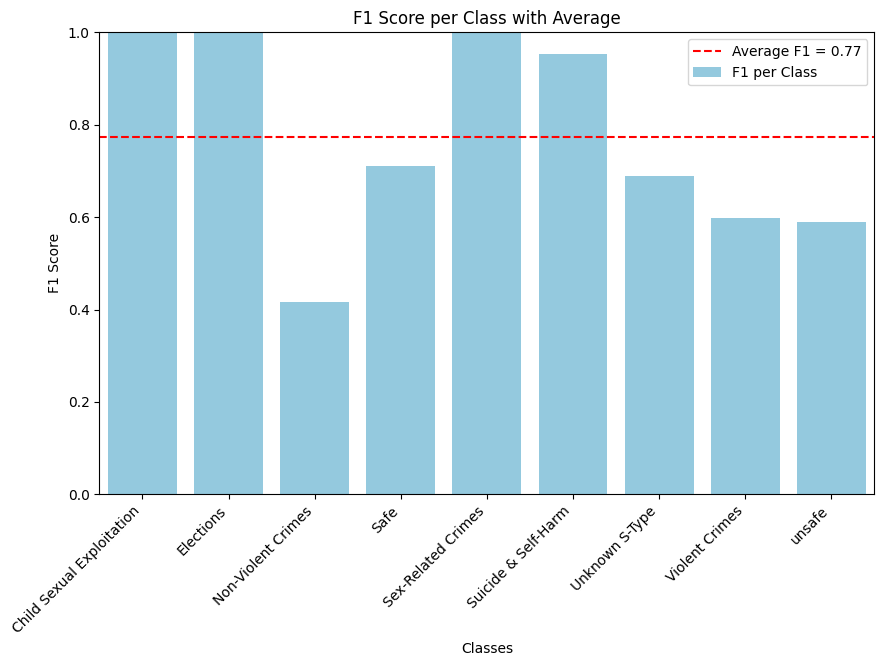

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
import numpy as np

# Predict
y_pred_probs = model_lstm_bi.predict(X_test)
y_pred_classes = tf.argmax(y_pred_probs, axis=-1).numpy()
y_true_classes = y_test
label_names = df['Toxic Category'].unique()
label_names = sorted(label_names)
# F1 per class
f1_per_class = f1_score(y_true_classes, y_pred_classes, average=None)


# Average F1
avg_f1 = np.mean(f1_per_class)

# Plot bar + line
plt.figure(figsize=(10,6))
sns.barplot(x=label_names, y=f1_per_class, color='skyblue', label='F1 per Class')
plt.axhline(avg_f1, color='red', linestyle='--', label=f'Average F1 = {avg_f1:.2f}')

plt.ylabel("F1 Score")
plt.xlabel("Classes")
plt.ylim(0, 1)
plt.title("F1 Score per Class with Average")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

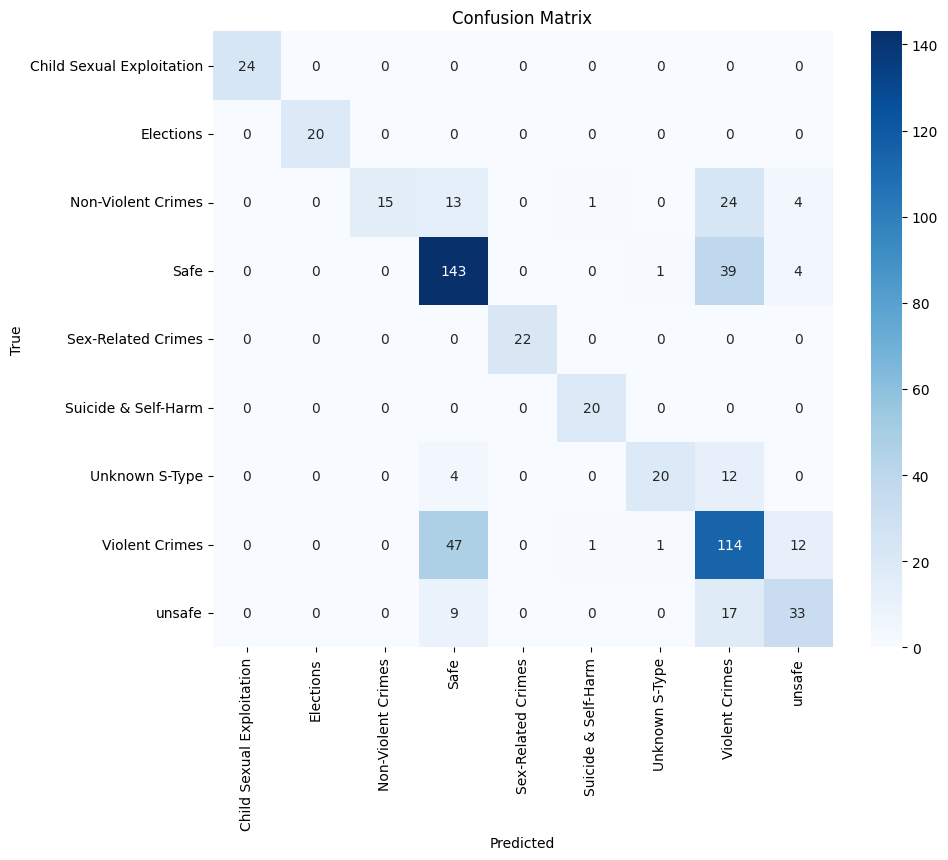

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()